In [26]:
path = r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-12\data\lev-12_merged.parquet"

# import 
import pandas as pd
import polars as pl
import missingno as msgo
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
colors = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59']  
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

palette = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59', '#ccff33', '#ff36ab', '#e0fbfc', '#3772ff', '#45062e']  
sns.set_palette(palette)

In [28]:

# Import Data and filter
pdf = pl.read_parquet(path)
display(f"Before Filtering the shape {pdf.shape}")
pdf = pdf.filter(
    pl.col('State') == '23'
)
display(f"After Filter the shape {pdf.shape}")

cols = [
'ITEM_CODE',
'QUANTITY',
'VALUE',
'MULTIPLIER',
]

pdf = pdf[cols]

display(f"Desire Filter shape {pdf.shape}")

# str -> int 
pdf = pdf.with_columns(
    [pl.col(col).cast(pl.Int16, strict=False) for col in pdf.columns]
)

display(pdf.schema)

# MP Data
mp_df = pdf.to_pandas()

'Before Filtering the shape (9414702, 22)'

'After Filter the shape (539656, 22)'

'Desire Filter shape (539656, 4)'

Schema([('ITEM_CODE', Int16),
        ('QUANTITY', Int16),
        ('VALUE', Int16),
        ('MULTIPLIER', Int16)])

In [29]:
mp_df

,ITEM_CODE,QUANTITY,VALUE,MULTIPLIER
0,351,3.0,1800.0,NaN
1,352,4.0,800.0,NaN
2,366,4.0,450.0,NaN
3,370,8.0,600.0,NaN
4,371,10.0,400.0,NaN
...,...,...,...,...
539651,371,8.0,760.0,NaN
539652,373,3.0,420.0,NaN
539653,383,2.0,1200.0,NaN
539654,393,9.0,2450.0,NaN


In [30]:
mp_df['ITEM_CODE'].unique()

array([351, 352, 366, 370, 371, 373, 380, 382, 393, 394,  31,  34, 354,
       356, 357, 363, 364, 367, 381, 355, 360, 361, 372, 362, 384, 385,
       368, 358, 390,  30, 365, 386, 353, 383,  33, 391, 350, 392,  32,
       374, 375, 395, 379, 399, 389], dtype=int16)

In [31]:
mapping = {
    351: "saree (no.)",
    352: "cloth for shirt, pyjama, kurta, salwar, etc. (metre)",
    366: "blouse, dupatta/stole (no.)",
    370: "innerwear, socks, hosiery items (no.)",
    371: "gamchha, towel, handkerchief (no.)",
    373: "headwear, belts, ties, hat, scarf, muffler, etc. (no.)",
    380: "bed sheet, bed cover (no.)",
    382: "pillow, cushion (no.)",
    393: "rubber / PVC footwear",
    394: "other footwear",
    31: "shirts (no.)",
    34: "track suit, track pant, joggers (no.)",
    354: "coat, jacket, blazer, sweater, sweatshirts, windcheater (no.)",
    356: "school/college uniform: boys",
    357: "school/college uniform: girls",
    363: "T-shirts, polos, tops, shrugs (no.)",
    364: "trousers, jeans, jeggings, skirts (no.)",
    367: "lungi (no.)",
    381: "rug, blanket (no.)",
    355: "shawl, chaddar (no.)",
    360: "kurta-pajama suits: females (no.)",
    361: "kurta, kameez, kurti (no.)",
    372: "infant clothing",
    362: "pajamas, salwar, leggings, plazzo (no.)",
    384: "cloth for upholstery, curtains, tablecloth, etc. (metre)",
    385: "mosquito net (no.)",
    368: "shorts, bermuda, nightdress, loungewear, etc.",
    358: "kurta-pajama suits: males (no.)",
    390: "leather boots, shoes",
    30: "face mask, gloves",
    365: "dresses, jumpsuits, frocks (no.)",
    386: "bedding: others",
    353: "cloth for coat, trousers, suit, etc. (metre)",
    383: "quilt, mattress (no.)",
    33: "sherwani, lehnga, gown (no.)",
    391: "leather sandals, chappals, etc.",
    350: "dhoti (no.)",
    392: "other leather footwear",
    32: "western suit set (no.)",
    374: "clothing (first-hand): other (incl. knitting wool)",
    375: "clothing: second-hand",
    395: "footwear: second-hand",
    379: "clothing: sub-total",
    399: "footwear: sub-total",
    389: "bedding, etc.: sub-total"
}

In [32]:
df = mp_df .copy()

In [33]:
df['Map_item'] = df['ITEM_CODE'].map(mapping)

In [34]:
mp_df.columns

Index(['ITEM_CODE', 'QUANTITY', 'VALUE', 'MULTIPLIER'], dtype='object')

In [38]:
df_q = df.groupby('Map_item')[['QUANTITY', 'VALUE']].mean()

df_q

,QUANTITY,VALUE
Map_item,,
"T-shirts, polos, tops, shrugs (no.)",3.995623,1065.087534
"bed sheet, bed cover (no.)",1.950261,547.667487
"bedding, etc.: sub-total",NaN,1155.063715
bedding: others,NaN,808.382353
"blouse, dupatta/stole (no.)",4.061233,624.420073
"cloth for coat, trousers, suit, etc. (metre)",4.945173,928.663290
"cloth for shirt, pyjama, kurta, salwar, etc. (metre)",6.949433,1036.787481
"cloth for upholstery, curtains, tablecloth, etc. (metre)",3.158609,596.072943
clothing (first-hand): other (incl. knitting wool),NaN,709.213043


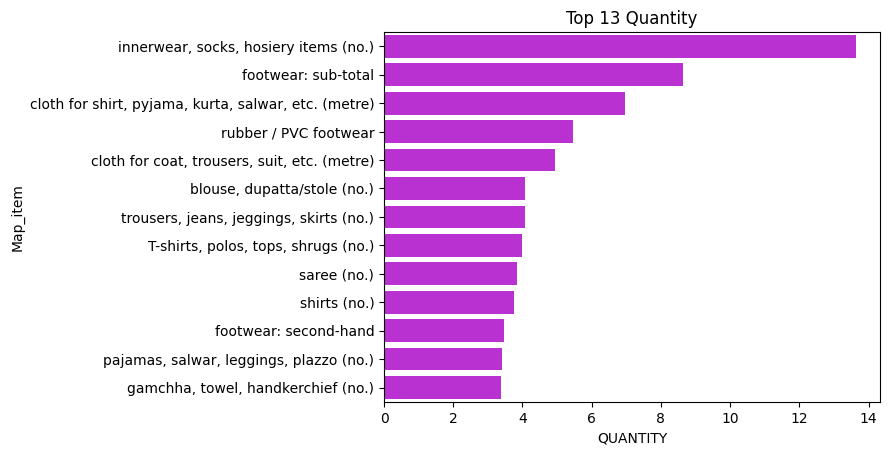

In [49]:
sns.barplot(df_q.sort_values(by='QUANTITY', ascending=False)['QUANTITY'].head(13), orient='h')
plt.title('Top 13 Quantity')
plt.show()

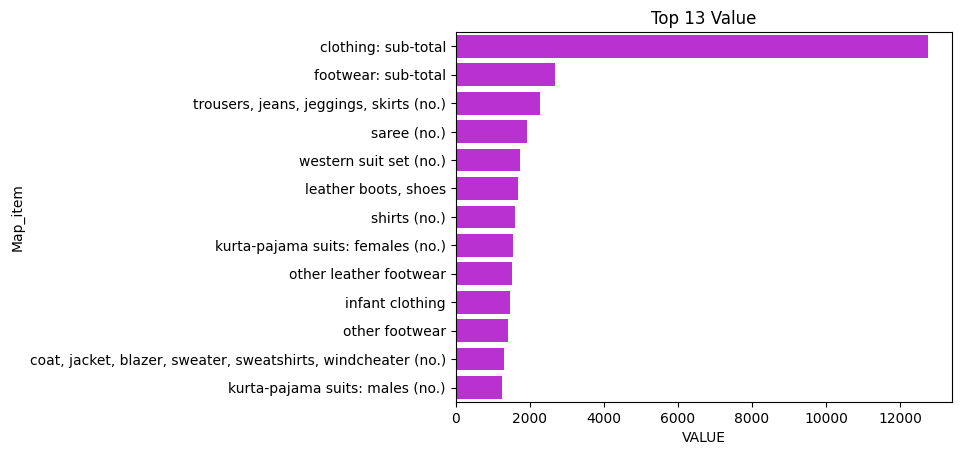

In [50]:
sns.barplot(df_q.sort_values(by='VALUE', ascending=False)['VALUE'].head(13), orient='h')
plt.title('Top 13 Value')
plt.show()

<Axes: xlabel='QUANTITY', ylabel='Map_item'>

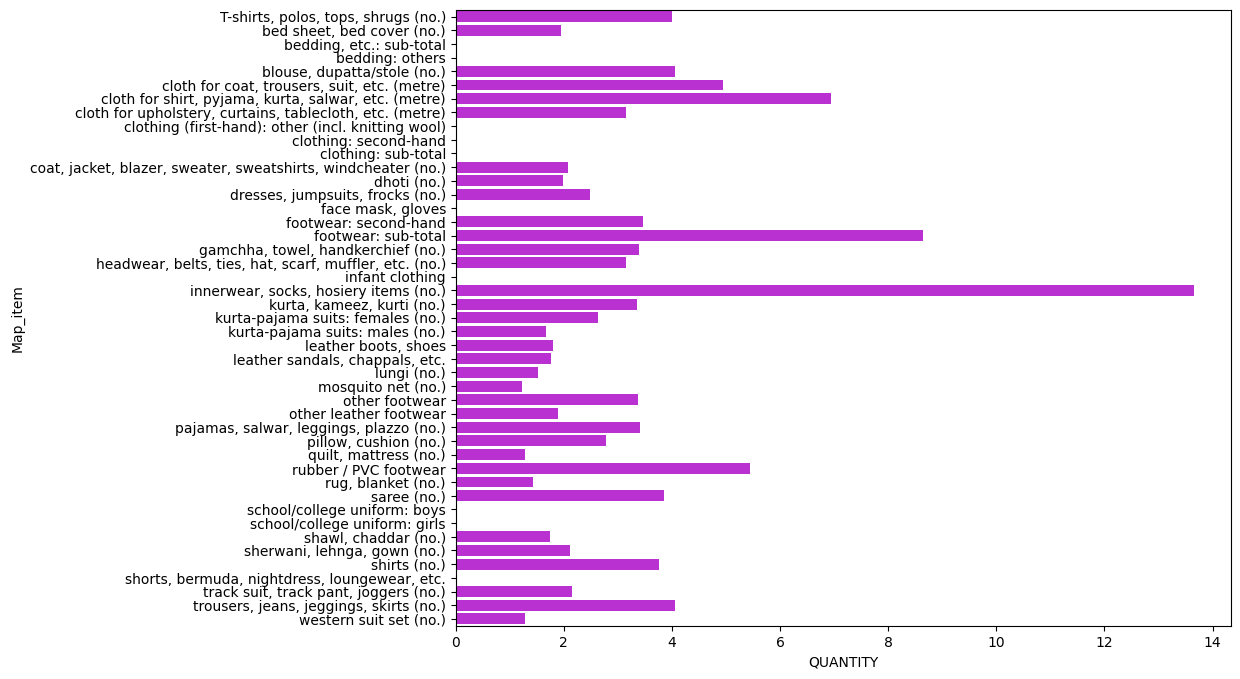

In [47]:
plt.figure(figsize=(10, 8))
sns.barplot(df.groupby('Map_item')['QUANTITY'].agg('mean'), orient='h')


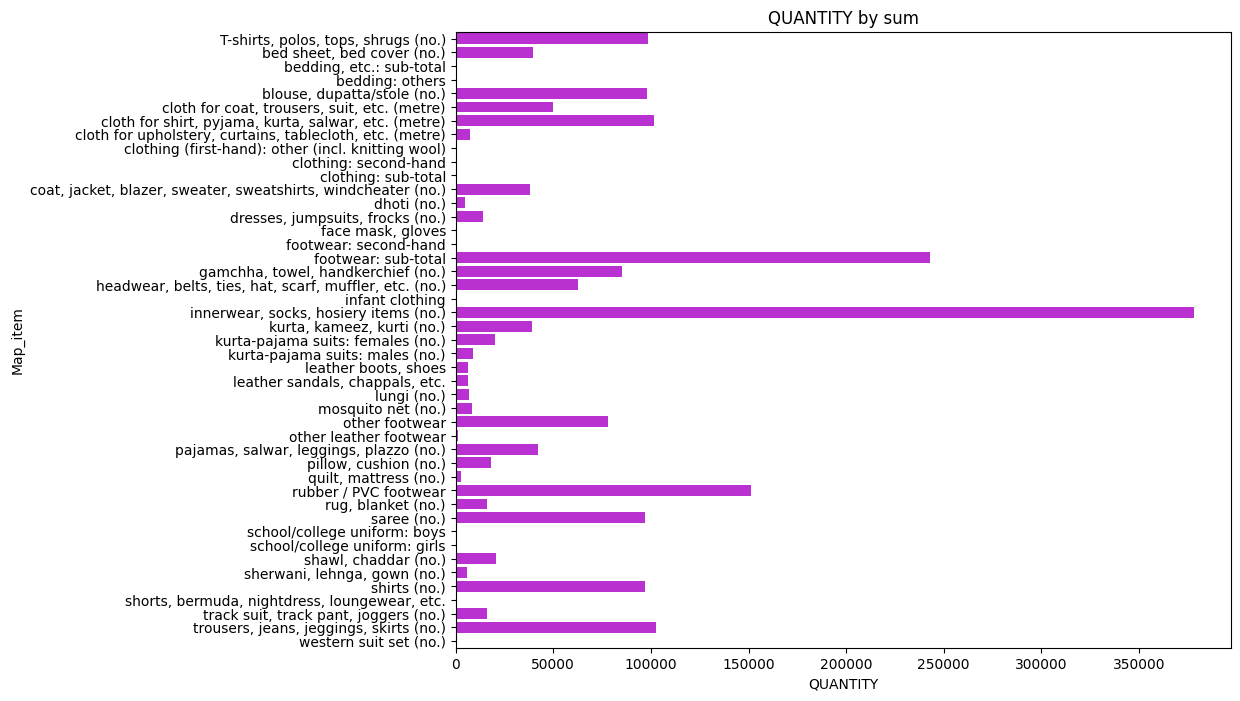

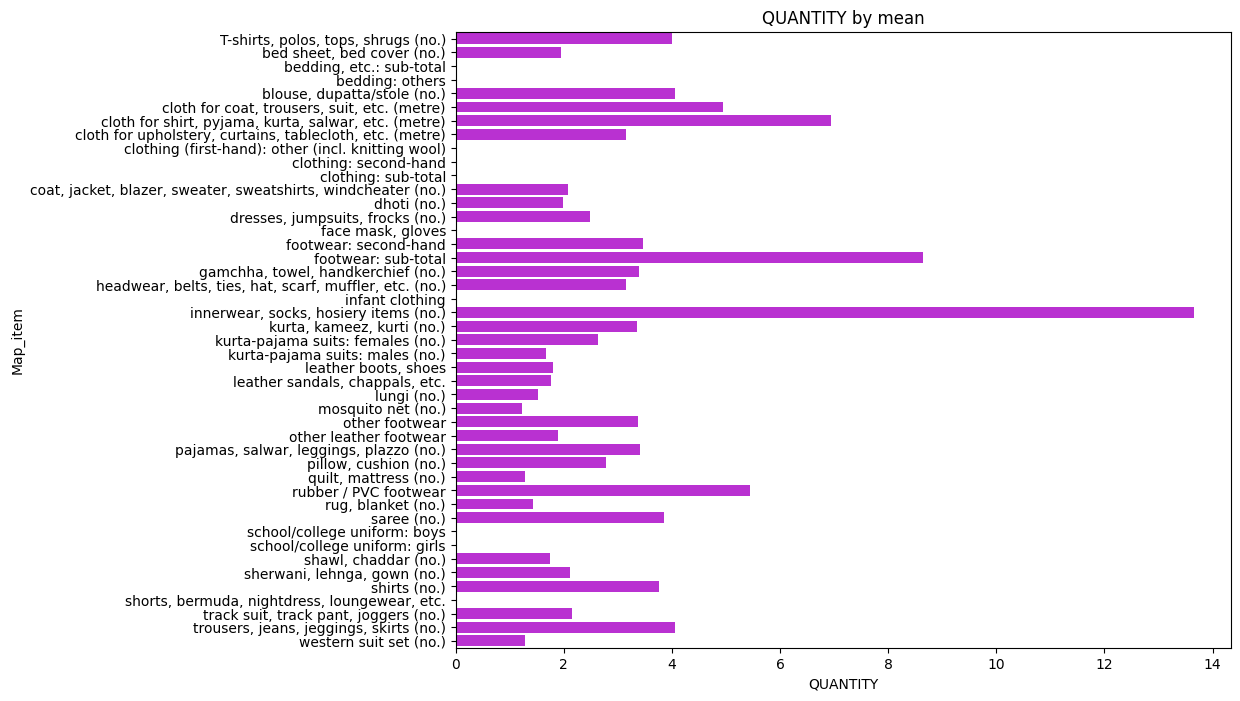

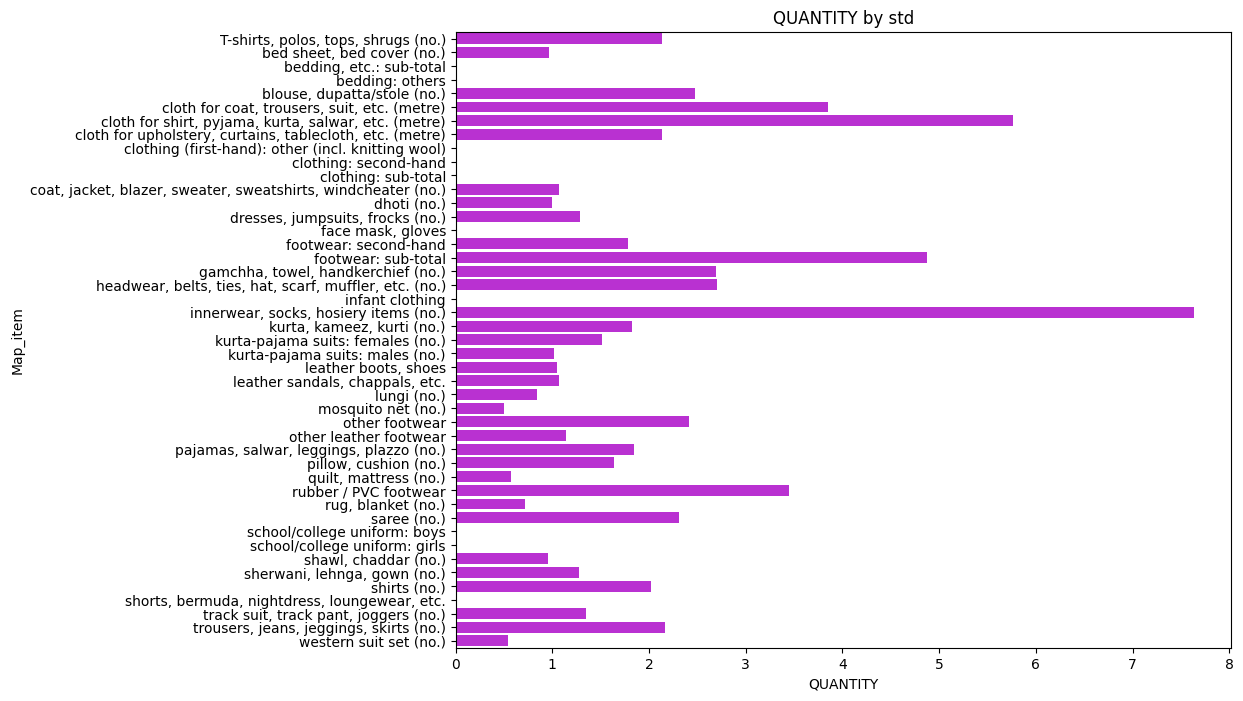

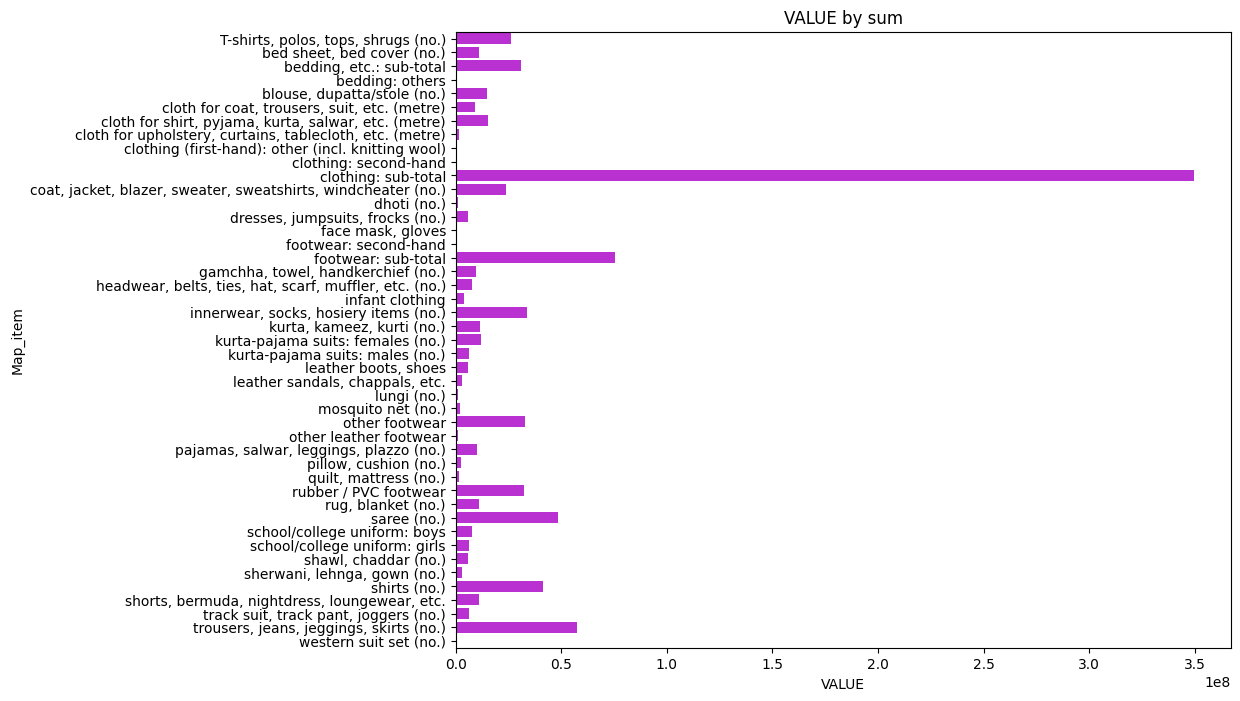

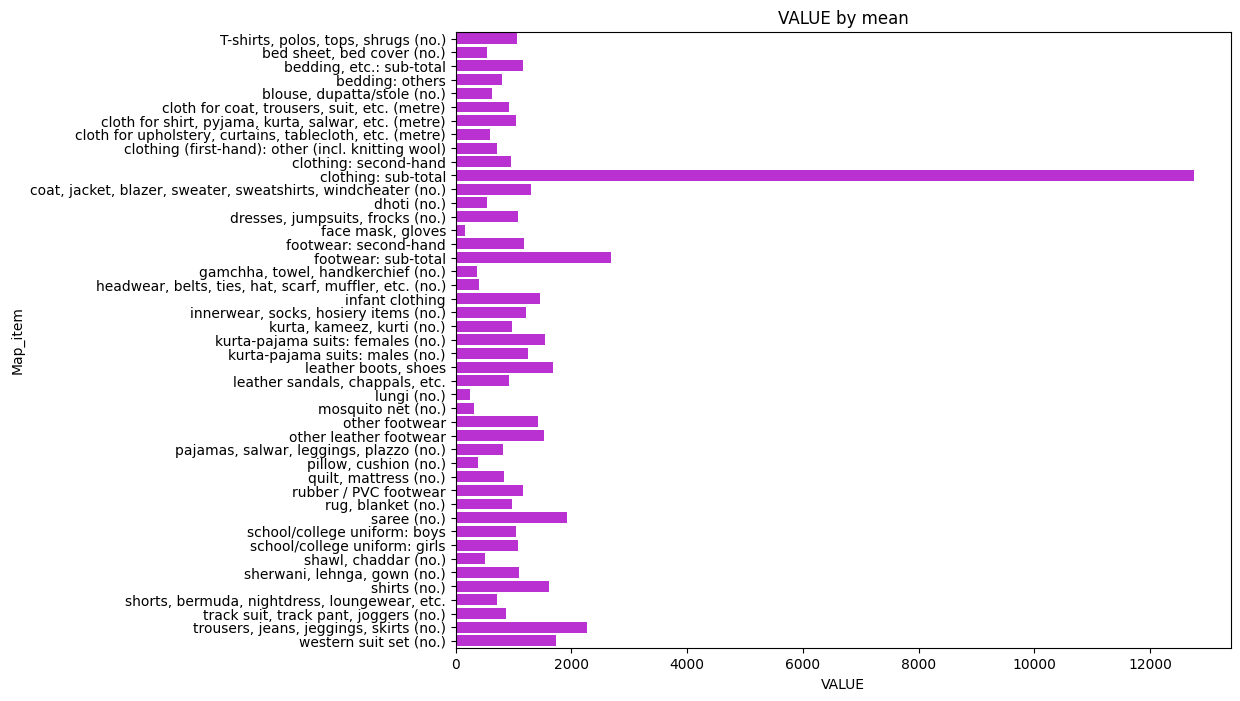

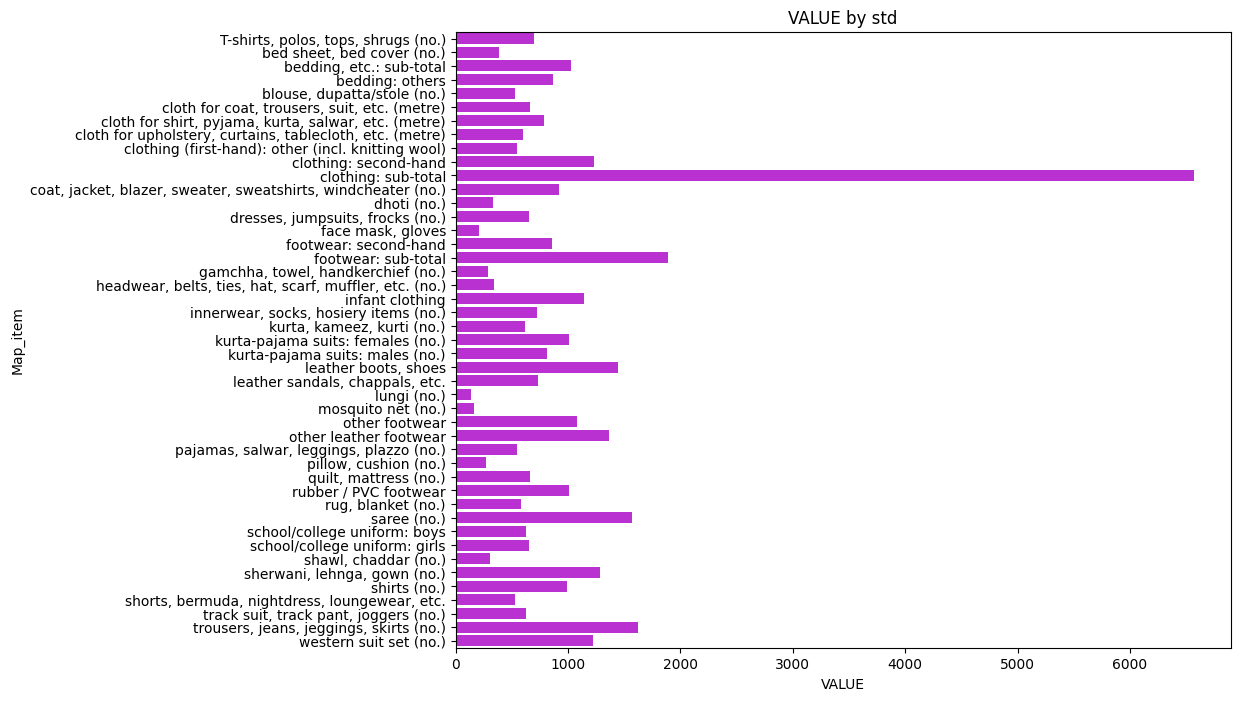

In [48]:
columns = ['QUANTITY', 'VALUE']

agg_functions = ['sum', 'mean', 'std']

for col in columns:
       for fun in agg_functions:
              plt.figure(figsize=(10, 8))
              sns.barplot(df.groupby('Map_item')[col].agg(fun), orient='h')
              plt.title(f"{col} by {fun}")
              plt.show()